#### STEP 1: Load Libraries

In [42]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency

#### STEP 2: Load Data

In [43]:
# Load the cleaned dataset
df = pd.read_csv("../data/processed/loans_cleaned.csv")

# Convert the data columns to datetime format
df["disbursement_date"] = pd.to_datetime(df["disbursement_date"])
df["due_date"] = pd.to_datetime(df["due_date"])

df.head()

,id,customer_id,country_id,tbl_loan_id,lender_id,loan_type,total_amount,total_amount_to_repay,disbursement_date,due_date,duration,new_versus_repeat,amount_funded_by_lender,lender_portion_funded,lender_portion_to_be_repaid,target
0,ID_257244237466267278,257244,Kenya,237466,267278,Type_1,16477.0,16642.0,2022-08-15,2022-08-22,7,Repeat Loan,2436.0,0.147842,2460.0,0
1,ID_249619214444267278,249619,Kenya,214444,267278,Type_1,5599.0,5599.0,2022-07-13,2022-07-20,7,Repeat Loan,2799.5,0.500000,2800.0,0
2,ID_251457257838267278,251457,Kenya,257838,267278,Type_1,4679.0,4746.0,2022-09-12,2022-09-19,7,Repeat Loan,7.8,0.001667,8.0,0
3,ID_266224270337267278,266224,Kenya,270337,267278,Type_1,6123.0,6123.0,2022-09-29,2022-10-06,7,Repeat Loan,318.8,0.052066,319.0,0
4,ID_250369246185267278,250369,Kenya,246185,267278,Type_1,2953.0,2974.0,2022-08-27,2022-09-03,7,Repeat Loan,15.0,0.005080,15.0,0


In [44]:
df.shape

(68654, 16)

In [45]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 68654 entries, 0 to 68653
Data columns (total 16 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   id                           68654 non-null  str           
 1   customer_id                  68654 non-null  int64         
 2   country_id                   68654 non-null  str           
 3   tbl_loan_id                  68654 non-null  int64         
 4   lender_id                    68654 non-null  int64         
 5   loan_type                    68654 non-null  str           
 6   total_amount                 68654 non-null  float64       
 7   total_amount_to_repay        68654 non-null  float64       
 8   disbursement_date            68654 non-null  datetime64[us]
 9   due_date                     68654 non-null  datetime64[us]
 10  duration                     68654 non-null  int64         
 11  new_versus_repeat            68654 non-null  str    

#### STEP 3: EDA

##### Univariate Analysis

In [46]:
# Distribution of the target variable
df["target"].value_counts(normalize=True)


target
0    0.981676
1    0.018324
Name: proportion, dtype: float64

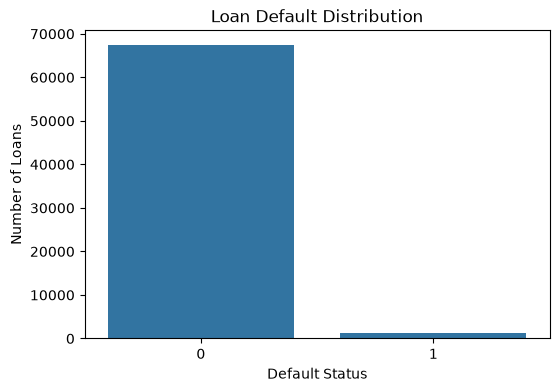

In [47]:
plt.figure(figsize=(6, 4))

sns.countplot(data=df, x='target')

plt.title('Loan Default Distribution')
plt.xlabel('Default Status')
plt.ylabel('Number of Loans')

plt.show()

__2. Distribution of Loan Amount__

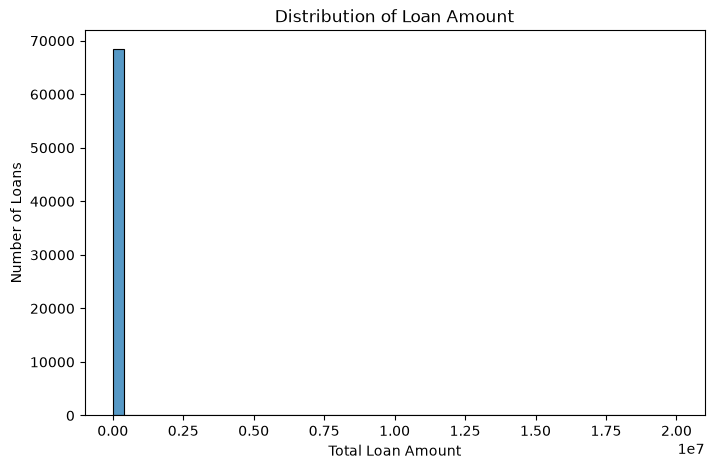

In [48]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x='total_amount',
    bins=50
)

plt.title('Distribution of Loan Amount')
plt.xlabel('Total Loan Amount')
plt.ylabel('Number of Loans')

plt.show()

__3. Distribution of Loan Duration__

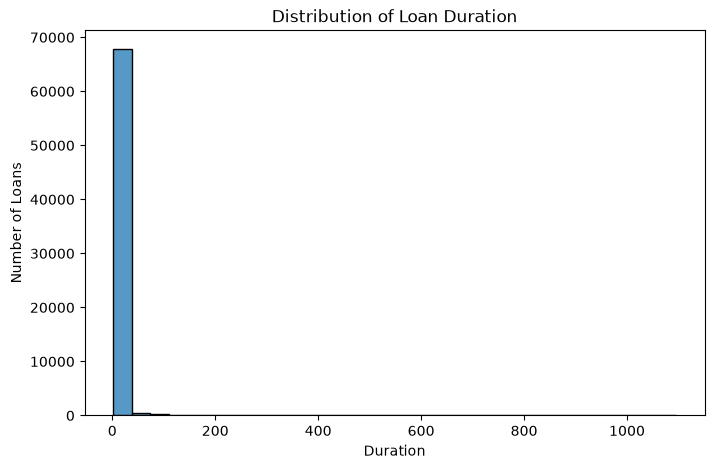

In [49]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x='duration',
    bins=30
)

plt.title('Distribution of Loan Duration')
plt.xlabel('Duration')
plt.ylabel('Number of Loans')

plt.show()

##### Bivariate Analysis

__1. Loan Type vs Target__

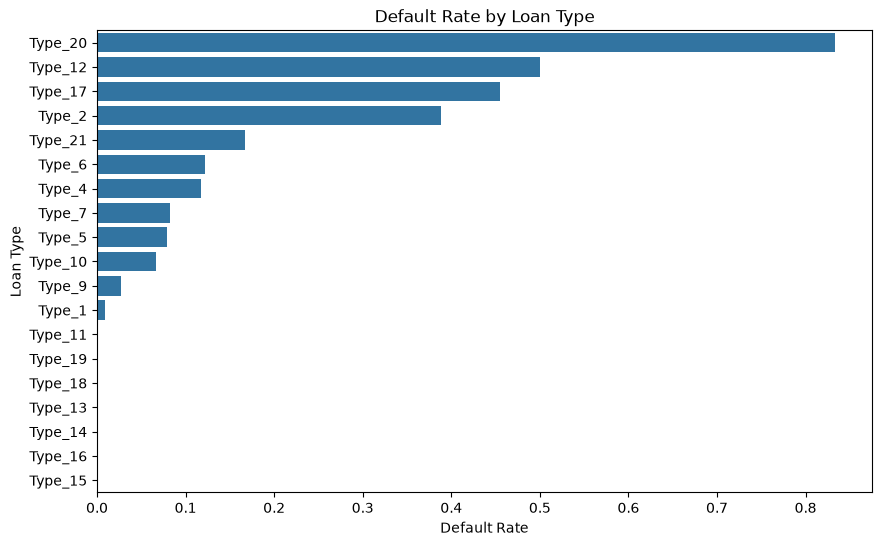

In [50]:
loan_type_rate = (
    df.groupby('loan_type')['target']
      .mean()
      .sort_values(ascending=False)
)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=loan_type_rate.values,
    y=loan_type_rate.index
)

plt.title('Default Rate by Loan Type')
plt.xlabel('Default Rate')
plt.ylabel('Loan Type')

plt.show()

In [51]:
loan_type_table = pd.crosstab(
    df['loan_type'],
    df['target']
)

chi2, p, dof, expected = chi2_contingency(loan_type_table)

print(f"Chi-square statistic: {chi2:.2f}")
print(f"p-value: {p:.4f}")
print(f"Degrees of freedom: {dof}")

Chi-square statistic: 5695.71
p-value: 0.0000
Degrees of freedom: 18


__2. New vs Repeat__

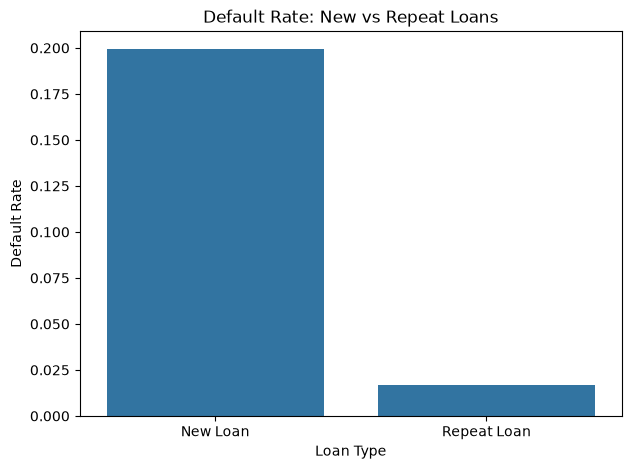

In [52]:
repeat_rate = (
    df.groupby('new_versus_repeat')['target']
      .mean()
)

plt.figure(figsize=(7, 5))

sns.barplot(
    x=repeat_rate.index,
    y=repeat_rate.values
)

plt.title('Default Rate: New vs Repeat Loans')
plt.xlabel('Loan Type')
plt.ylabel('Default Rate')

plt.show()


In [54]:
repeat_table = pd.crosstab(
    df['new_versus_repeat'],
    df['target']
)

chi2, p, dof, expected = chi2_contingency(repeat_table)

print(f"Chi-square statistic: {chi2:.2f}")
print(f"p-value: {p:.4f}")
print(f"Degrees of freedom: {dof}")

Chi-square statistic: 984.19
p-value: 0.0000
Degrees of freedom: 1


__3. Loan Amount vs Target__

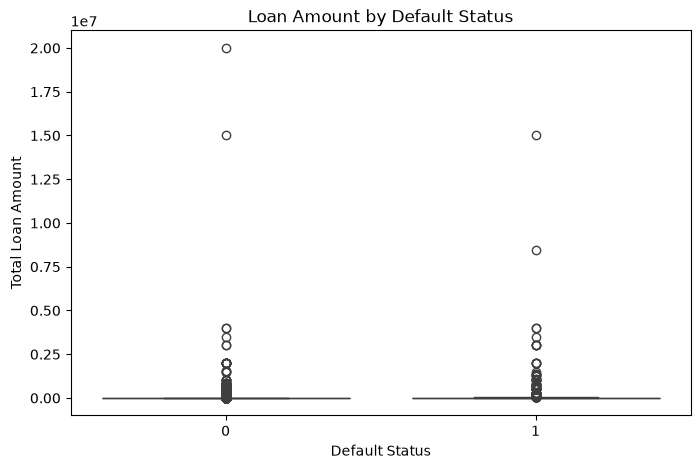

In [ ]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x='target',
    y='total_amount'
)

plt.title('Loan Amount by Default Status')
plt.xlabel('Default Status')
plt.ylabel('Total Loan Amount')

plt.show()

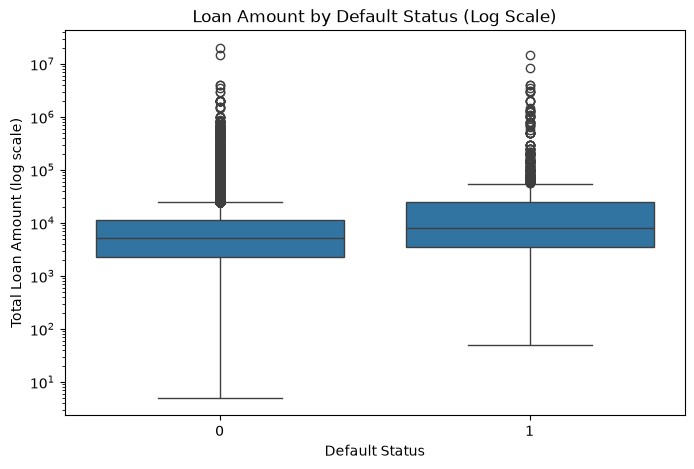

In [ ]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x='target',
    y='total_amount'
)

plt.yscale('log')

plt.title('Loan Amount by Default Status (Log Scale)')
plt.xlabel('Default Status')
plt.ylabel('Total Loan Amount (log scale)')

plt.show()

__4. Lender_id vs target__

In [55]:
lender_table = pd.crosstab(
    df['lender_id'],
    df['target']
)

chi2, p, dof, expected = chi2_contingency(lender_table)

print(f"Chi-square statistic: {chi2:.2f}")
print(f"p-value: {p:.4f}")
print(f"Degrees of freedom: {dof}")

Chi-square statistic: 3488.05
p-value: 0.0000
Degrees of freedom: 3


#### Multivariate Analysis

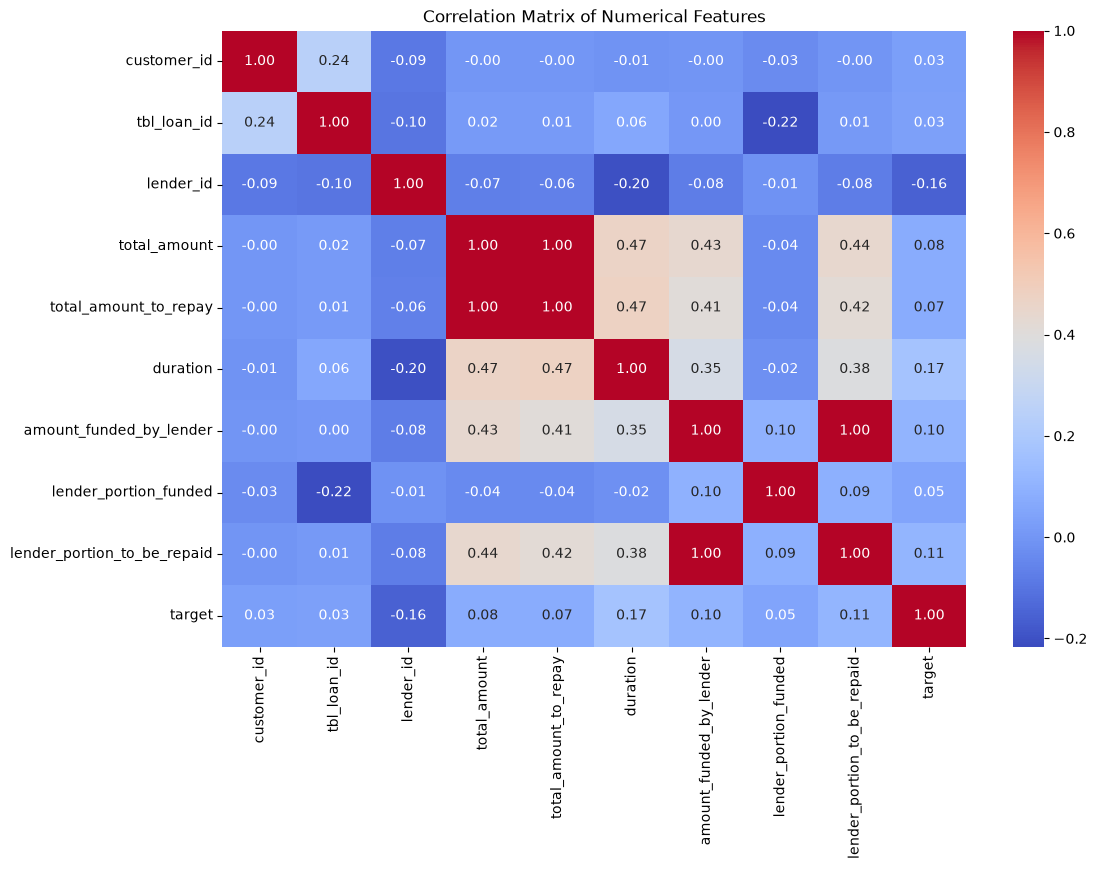

In [ ]:
# Correlation matrix of numerical features
numeric_cols = df.select_dtypes(include='number').columns

plt.figure(figsize=(12, 8))

sns.heatmap(
    df[numeric_cols].corr(),
    annot=True,
    fmt='.2f',
    cmap='coolwarm'
)

plt.title('Correlation Matrix of Numerical Features')
plt.show()

In [ ]:
df[
    [
        'total_amount',
        'total_amount_to_repay',
        'amount_funded_by_lender',
        'lender_portion_funded',
        'lender_portion_to_be_repaid'
    ]
].corr()

,total_amount,total_amount_to_repay,amount_funded_by_lender,lender_portion_funded,lender_portion_to_be_repaid
total_amount,1.000000,0.997512,0.434888,-0.040187,0.441329
total_amount_to_repay,0.997512,1.000000,0.410673,-0.037044,0.419561
amount_funded_by_lender,0.434888,0.410673,1.000000,0.096645,0.997459
lender_portion_funded,-0.040187,-0.037044,0.096645,1.000000,0.088441
lender_portion_to_be_repaid,0.441329,0.419561,0.997459,0.088441,1.000000
